In [1]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
import time

# Tratamento e Limpeza

In [2]:
# Leitura dos arquivos csv e tsv

df_movies = pd.read_csv('movies_metadata.csv')

df_basics = pd.read_table('title.basics.tsv.gz')

df_rating = pd.read_table('title.ratings.tsv.gz')

C:\Users\User\AppData\Local\Temp\ipykernel_14436\3404999718.py:3: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('movies_metadata.csv')


In [3]:
# Analisamos todas as colunas
df_movies.columns

# Escolhemos apenas as colunas uteis para analise
colunas_uteis = ['id', 'imdb_id', 'title', 'budget', 'revenue', 'release_date', 'runtime', 'popularity', 'vote_average', 'vote_count', 'genres']

# Substituimos o dataset apenas com as colunas uteis
df_movies = df_movies[colunas_uteis]

In [4]:
# Analisamos todas as colunas
df_basics.columns

# Escolhemos apenas as colunas uteis para analise
colunas_uteis = ['tconst', 'titleType', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']

# Substituimos o dataset apenas com as colunas uteis
df_basics = df_basics[colunas_uteis]

In [5]:
# Filtrando por apenas filmes porque possui serie e curtas
df_basics = df_basics[df_basics['titleType'] == 'movie']

# Dropando a coluna porque esta filtrado para apenas filmes
df_basics = df_basics.drop('titleType', axis=1)

In [6]:
# Analise dos nulos antes do tratamento
print(df_movies.isnull().sum(), '\n')
print(df_basics.isnull().sum(), '\n')
print(df_rating.isnull().sum(), '\n')

id                0
imdb_id          17
title             6
budget            0
revenue           6
release_date     87
runtime         263
popularity        5
vote_average      6
vote_count        6
genres            0
dtype: int64 

tconst            0
primaryTitle      3
startYear         0
runtimeMinutes    0
genres            0
dtype: int64 

tconst           0
averageRating    0
numVotes         0
dtype: int64 



In [7]:
# Dropando valores nulos em colunas essenciais

df_basics = df_basics.dropna(subset=['primaryTitle'])

df_movies = df_movies.dropna(subset=['imdb_id', 'title', 'release_date', 'runtime'])

In [8]:
# Analise dos nulos após tratamento
print(df_movies.isnull().sum(), '\n')
print(df_basics.isnull().sum(), '\n')
print(df_rating.isnull().sum(), '\n')

id              0
imdb_id         0
title           0
budget          0
revenue         0
release_date    0
runtime         0
popularity      0
vote_average    0
vote_count      0
genres          0
dtype: int64 

tconst            0
primaryTitle      0
startYear         0
runtimeMinutes    0
genres            0
dtype: int64 

tconst           0
averageRating    0
numVotes         0
dtype: int64 



In [9]:
# Renomeando colunas para  merge

df_basics.rename(columns={'tconst': 'imdb_id'}, inplace=True)

df_rating.rename(columns={'tconst': 'imdb_id'}, inplace=True)


In [10]:
# Removemos a coluna starYear porque usaremos a coluna release_date do df_movies

df_basics = df_basics.drop('startYear', axis=1)

# Removemos a coluna runtimeMinutes porque usaremos a coluna runtime de df_movies

df_basics = df_basics.drop('runtimeMinutes', axis=1)

# Removemos a coluna genres de df_movies porque esta em json

df_movies = df_movies.drop('genres', axis=1)

# Removemos as colunas de vote do df_movies por causa que podem estar desatualizadas enquanto as do df_rating são atualizadas pelo imdb

df_movies = df_movies.drop(columns=['vote_average', 'vote_count'])

In [11]:
# Visualizando como ficou o dataframe
df_movies.head()

,id,imdb_id,title,budget,revenue,release_date,runtime,popularity
0,862,tt0114709,Toy Story,30000000,373554033.0,1995-10-30,81.0,21.946943
1,8844,tt0113497,Jumanji,65000000,262797249.0,1995-12-15,104.0,17.015539
2,15602,tt0113228,Grumpier Old Men,0,0.0,1995-12-22,101.0,11.7129
3,31357,tt0114885,Waiting to Exhale,16000000,81452156.0,1995-12-22,127.0,3.859495
4,11862,tt0113041,Father of the Bride Part II,0,76578911.0,1995-02-10,106.0,8.387519


In [12]:
# Visualizando como ficou o dataframe
df_rating.head()

,imdb_id,averageRating,numVotes
0,tt0000001,5.7,2211
1,tt0000002,5.4,319
2,tt0000003,6.4,2344
3,tt0000004,5.1,192
4,tt0000005,6.2,3059


In [13]:
# Visualizando como ficou o dataframe
df_basics.head()

,imdb_id,primaryTitle,genres
8,tt0000009,Miss Jerry,Romance
144,tt0000147,The Corbett-Fitzsimmons Fight,"Documentary,News,Sport"
498,tt0000502,Bohemios,\N
570,tt0000574,The Story of the Kelly Gang,"Action,Adventure,Biography"
587,tt0000591,The Prodigal Son,Drama


In [14]:
# Começando o merge
# Primeiro merge entre rating e movies
df_final = pd.merge(df_movies, df_rating, on='imdb_id', how='inner')

# Segundo merge que junto o basics apenas com as colunas imdb e genres
df_final = pd.merge(df_final, df_basics[['imdb_id', 'genres']], on='imdb_id', how='inner')

In [15]:
# Verificando o dataframe combinado
df_final.head()

,id,imdb_id,title,budget,revenue,release_date,runtime,popularity,averageRating,numVotes,genres
0,862,tt0114709,Toy Story,30000000,373554033.0,1995-10-30,81.0,21.946943,8.3,1176535,"Adventure,Animation,Comedy"
1,8844,tt0113497,Jumanji,65000000,262797249.0,1995-12-15,104.0,17.015539,7.1,414470,"Adventure,Comedy,Family"
2,15602,tt0113228,Grumpier Old Men,0,0.0,1995-12-22,101.0,11.7129,6.7,31720,"Comedy,Romance"
3,31357,tt0114885,Waiting to Exhale,16000000,81452156.0,1995-12-22,127.0,3.859495,6.0,14008,"Comedy,Drama,Romance"
4,11862,tt0113041,Father of the Bride Part II,0,76578911.0,1995-02-10,106.0,8.387519,6.1,45316,"Comedy,Family,Romance"


In [16]:
# Verificando orçamentos e faturamentos zerados
# Convertemos primeiro para float caso não esteja
df_final['budget'] = df_final['budget'].astype(float)
df_final['revenue'] = df_final['revenue'].astype(float)

qtd_zeros_budget = (df_final['budget'] == 0).sum()
qtd_zeros_revenue = (df_final['revenue'] == 0).sum()

print(f"Orçamentos zerados: {qtd_zeros_budget}")
print(f"Faturamentos zerados: {qtd_zeros_revenue}")

# Verificando as strings nulas do IMDb (\N)
qtd_zeros_genres = (df_final['genres'] == '\\N').sum()

print(f"Gêneros como '\\N': {qtd_zeros_genres}")

Orçamentos zerados: 30423
Faturamentos zerados: 31513
Gêneros como '\N': 12


In [17]:
# Escolhemos tirar todos os filmes que não possuem orçamento e faturamento
df_final = df_final[(df_final['budget'] > 0) & (df_final['revenue'] > 0)]

# Limpando os falsos nulos do IMDb
df_final = df_final[df_final['genres'] != '\\N']

# Mexemos também no runtime para não ter zeros
df_final['runtime'] = df_final['runtime'].astype(float)
df_final = df_final[df_final['runtime'] > 0]

In [18]:
# Dataset após organização
df_final.head()

,id,imdb_id,title,budget,revenue,release_date,runtime,popularity,averageRating,numVotes,genres
0,862,tt0114709,Toy Story,30000000.0,373554033.0,1995-10-30,81.0,21.946943,8.3,1176535,"Adventure,Animation,Comedy"
1,8844,tt0113497,Jumanji,65000000.0,262797249.0,1995-12-15,104.0,17.015539,7.1,414470,"Adventure,Comedy,Family"
3,31357,tt0114885,Waiting to Exhale,16000000.0,81452156.0,1995-12-22,127.0,3.859495,6.0,14008,"Comedy,Drama,Romance"
5,949,tt0113277,Heat,60000000.0,187436818.0,1995-12-15,170.0,17.924927,8.3,806505,"Action,Crime,Drama"
8,9091,tt0114576,Sudden Death,35000000.0,64350171.0,1995-12-22,106.0,5.23158,5.9,39661,"Action,Crime,Thriller"


In [19]:
# Vendo as informações do dataset
df_final.info()

<class 'pandas.DataFrame'>
Index: 5355 entries, 0 to 38846
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             5355 non-null   str    
 1   imdb_id        5355 non-null   str    
 2   title          5355 non-null   str    
 3   budget         5355 non-null   float64
 4   revenue        5355 non-null   float64
 5   release_date   5355 non-null   str    
 6   runtime        5355 non-null   float64
 7   popularity     5355 non-null   object 
 8   averageRating  5355 non-null   float64
 9   numVotes       5355 non-null   int64  
 10  genres         5355 non-null   str    
dtypes: float64(4), int64(1), object(1), str(5)
memory usage: 502.0+ KB


In [20]:
# Convertendo release_date em date e popularity em float

df_final['release_date'] = pd.to_datetime(df_final['release_date'], format='%Y-%m-%d')

df_final['popularity'] = df_final['popularity'].astype(float)

In [21]:
# Vendo se os tipos estão agora certos
df_final.info()

<class 'pandas.DataFrame'>
Index: 5355 entries, 0 to 38846
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             5355 non-null   str           
 1   imdb_id        5355 non-null   str           
 2   title          5355 non-null   str           
 3   budget         5355 non-null   float64       
 4   revenue        5355 non-null   float64       
 5   release_date   5355 non-null   datetime64[us]
 6   runtime        5355 non-null   float64       
 7   popularity     5355 non-null   float64       
 8   averageRating  5355 non-null   float64       
 9   numVotes       5355 non-null   int64         
 10  genres         5355 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), str(4)
memory usage: 502.0 KB


# Pegando API
## Tratamento e Limpeza

In [22]:
# Configurando a API do TMDB

load_dotenv("tmdb.env")
API_KEY = os.getenv("TMDB_API_KEY")

if not API_KEY:
    raise ValueError("TMDB_API_KEY não encontrada no .env. Verifique o arquivo.")

BASE_URL = "https://api.themoviedb.org/3"

In [23]:
# Função para buscar detalhes de um filme pelo id do TMDB
# Com timeout e retry: sem isso, uma única requisição que trava
# pode deixar o loop inteiro parado para sempre

def buscar_detalhes_filme(tmdb_id, max_tentativas=2, timeout=8):
    url = f"{BASE_URL}/movie/{int(tmdb_id)}"
    params = {"api_key": API_KEY, "language": "en-US"}

    for tentativa in range(max_tentativas):
        try:
            return requests.get(url, params=params, timeout=timeout)
        except requests.exceptions.RequestException:
            if tentativa < max_tentativas - 1:
                time.sleep(1)
                continue
            return None
    return None

In [24]:
# Extração principal: para cada filme, busca franquia, estúdio, idioma e país
# Salva em cache (tmdbAPI_dados.csv) para não precisar chamar a API de novo
# toda vez que o notebook for reaberto

if os.path.exists("tmdbAPI_dados.csv"):
    df_api = pd.read_csv("tmdbAPI_dados.csv")
    print("Carregado do cache, sem chamar a API.")

else:
    resultados = []
    total = len(df_final)
    falhas = 0
    inicio = time.time()

    for i, row in df_final.iterrows():
        resp = buscar_detalhes_filme(row["id"])

        if resp is not None and resp.status_code == 200:
            dados = resp.json()

            colecao = dados.get("belongs_to_collection")
            franquia = colecao["name"] if colecao else None

            estudios = dados.get("production_companies", [])
            estudio_principal = estudios[0]["name"] if estudios else None

            paises = dados.get("production_countries", [])
            pais_producao = ", ".join([p["name"] for p in paises]) if paises else None

            resultados.append({
                "id": row["id"],
                "franquia": franquia,
                "is_franchise": colecao is not None,
                "estudio_principal": estudio_principal,
                "original_language": dados.get("original_language"),
                "production_countries": pais_producao,
                "status": dados.get("status"),
            })

        else:
            falhas += 1
            resultados.append({
                "id": row["id"],
                "franquia": None,
                "is_franchise": None,
                "estudio_principal": None,
                "original_language": None,
                "production_countries": None,
                "status": None,
            })

        if (i + 1) % 10 == 0 or (i + 1) == total:
            decorrido = time.time() - inicio
            print(f"Progresso: {i + 1}/{total} | falhas: {falhas} | tempo: {decorrido:.0f}s")

        time.sleep(0.03)

    df_api = pd.DataFrame(resultados)
    df_api.to_csv("tmdbAPI_dados.csv", index=False)
    print(f"\nConcluído e salvo em cache. {falhas} filme(s) sem dados.")

Carregado do cache, sem chamar a API.


In [25]:
# Visualizando como ficou o dataframe da API
df_api.head()

,id,franquia,is_franchise,estudio_principal,original_language,production_countries,status
0,862,Toy Story Collection,True,Pixar,en,United States of America,Released
1,8844,Jumanji Collection,True,TriStar Pictures,en,United States of America,Released
2,31357,NaN,False,20th Century Fox,en,United States of America,Released
3,949,Heat Collection,True,Warner Bros. Pictures,en,United States of America,Released
4,9091,NaN,False,Shattered Productions,en,United States of America,Released


In [26]:
# Todos os filmes são released então podemos dropar a coluna status
df_api['status'].value_counts()

df_api = df_api.drop(columns=['status'])

In [27]:
df_api.isnull().sum()

id                         0
franquia                3970
is_franchise               0
estudio_principal         45
original_language          0
production_countries      10
dtype: int64

In [28]:
# Renomeando  para não ficar nulo
df_api['franquia'] = df_api['franquia'].fillna('Sem franquia')

# Dropando a coluna is_franchise porque ao nomear os nulos da coluna franquia já é possível analisar
df_api = df_api.drop(columns=['is_franchise'])

# Renomeando quem não tem estudio principal
df_api['estudio_principal'] = df_api['estudio_principal'].fillna('Não informado')

# Nomeando quem não tem paises de produção
df_api['production_countries'] = df_api['production_countries'].fillna('Não informado')

# Verificando se tratou todos os nulos
df_api.isnull().sum()

id                      0
franquia                0
estudio_principal       0
original_language       0
production_countries    0
dtype: int64

# Merge API e csv
# Tratamento e Limpeza Finais

In [29]:
# Convertendo para string para o merge
df_api['id'] = df_api['id'].astype(str)

# Merge final usando o id do TMDB como chave
df_final = pd.merge(df_final, df_api, on="id", how="left")

In [30]:
# Visualizando como ficou o dataframe merge final
df_final.head()

,id,imdb_id,title,budget,revenue,release_date,runtime,popularity,averageRating,numVotes,genres,franquia,estudio_principal,original_language,production_countries
0,862,tt0114709,Toy Story,30000000.0,373554033.0,1995-10-30,81.0,21.946943,8.3,1176535,"Adventure,Animation,Comedy",Toy Story Collection,Pixar,en,United States of America
1,8844,tt0113497,Jumanji,65000000.0,262797249.0,1995-12-15,104.0,17.015539,7.1,414470,"Adventure,Comedy,Family",Jumanji Collection,TriStar Pictures,en,United States of America
2,31357,tt0114885,Waiting to Exhale,16000000.0,81452156.0,1995-12-22,127.0,3.859495,6.0,14008,"Comedy,Drama,Romance",Sem franquia,20th Century Fox,en,United States of America
3,949,tt0113277,Heat,60000000.0,187436818.0,1995-12-15,170.0,17.924927,8.3,806505,"Action,Crime,Drama",Heat Collection,Warner Bros. Pictures,en,United States of America
4,9091,tt0114576,Sudden Death,35000000.0,64350171.0,1995-12-22,106.0,5.231580,5.9,39661,"Action,Crime,Thriller",Sem franquia,Shattered Productions,en,United States of America


In [31]:
# Renomeando as colunas para melhor orientação e clareza
df_final = df_final.rename(columns={
    'id':                   'tmdb_id',
    'budget':               'orcamento',
    'revenue':              'receita',
    'release_date':         'data_lancamento',
    'runtime':              'duracao_min',
    'popularity':           'popularidade',
    'averageRating':        'nota_media',
    'numVotes':             'num_votos',
    'genres':               'generos',
    'estudio_principal':    'estudio',
    'original_language':    'idioma_original',
    'production_countries': 'paises_producao',
})

In [32]:
# Vendo as informações do dataframe final
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 5367 entries, 0 to 5366
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tmdb_id          5367 non-null   str           
 1   imdb_id          5367 non-null   str           
 2   title            5367 non-null   str           
 3   orcamento        5367 non-null   float64       
 4   receita          5367 non-null   float64       
 5   data_lancamento  5367 non-null   datetime64[us]
 6   duracao_min      5367 non-null   float64       
 7   popularidade     5367 non-null   float64       
 8   nota_media       5367 non-null   float64       
 9   num_votos        5367 non-null   int64         
 10  generos          5367 non-null   str           
 11  franquia         5367 non-null   str           
 12  estudio          5367 non-null   str           
 13  idioma_original  5367 non-null   str           
 14  paises_producao  5367 non-null   str           
dty

In [33]:
# Criando coluna de lucro e ROI para análises de performance financeira
df_final['lucro'] = df_final['receita'] - df_final['orcamento']
df_final['roi'] = (df_final['lucro'] / df_final['orcamento']) * 100

# Extraindo ano e agrupando por década para análise de período
df_final['ano'] = df_final['data_lancamento'].dt.year
df_final['decada'] = (df_final['ano'] // 10 * 10).astype(str) + 's'

# Simplificando idioma e país para comparação binária
# Analise para responder se a lingua inglesa ou ser feito no EUA influencia as perfomances dos filmes
df_final['idioma_ingles'] = df_final['idioma_original'] == 'en'
df_final['produzido_eua'] = df_final['paises_producao'].str.contains('United States of America', na=False)

# Extraindo o primeiro gênero listado como gênero principal
df_final['genero_principal'] = df_final['generos'].str.split(',').str[0]

# Filmes acima da mediana de votos têm nota mais representativa
# Para analise de correlação entre numero de votos e nota média 
mediana_votos = df_final['num_votos'].median()
df_final['voto_confiavel'] = df_final['num_votos'] >= mediana_votos

In [34]:
# Verificando o dataframe após adição das colunas novas
df_final.head()

,tmdb_id,imdb_id,title,orcamento,receita,data_lancamento,duracao_min,popularidade,nota_media,num_votos,...,idioma_original,paises_producao,lucro,roi,ano,decada,idioma_ingles,produzido_eua,genero_principal,voto_confiavel
0,862,tt0114709,Toy Story,30000000.0,373554033.0,1995-10-30,81.0,21.946943,8.3,1176535,...,en,United States of America,343554033.0,1145.180110,1995,1990s,True,True,Adventure,True
1,8844,tt0113497,Jumanji,65000000.0,262797249.0,1995-12-15,104.0,17.015539,7.1,414470,...,en,United States of America,197797249.0,304.303460,1995,1990s,True,True,Adventure,True
2,31357,tt0114885,Waiting to Exhale,16000000.0,81452156.0,1995-12-22,127.0,3.859495,6.0,14008,...,en,United States of America,65452156.0,409.075975,1995,1990s,True,True,Comedy,False
3,949,tt0113277,Heat,60000000.0,187436818.0,1995-12-15,170.0,17.924927,8.3,806505,...,en,United States of America,127436818.0,212.394697,1995,1990s,True,True,Action,True
4,9091,tt0114576,Sudden Death,35000000.0,64350171.0,1995-12-22,106.0,5.231580,5.9,39661,...,en,United States of America,29350171.0,83.857631,1995,1990s,True,True,Action,False


In [35]:
# Checando NaN nativo do pandas
print(df_final['roi'].isna().sum())

# Checando os valores únicos suspeitos
print(df_final[df_final['roi'] == 0][['title', 'orcamento', 'receita', 'lucro', 'roi']])

0
                          title  orcamento    receita  lucro  roi
975       The War of the Worlds  2000000.0  2000000.0    0.0  0.0
2874                   F.I.S.T.       11.0       11.0    0.0  0.0
3387  Kandukondain Kandukondain   500000.0   500000.0    0.0  0.0
3636                      Narco   823258.0   823258.0    0.0  0.0
3669               Bran Nue Dae        7.0        7.0    0.0  0.0
4813                  Treehouse  3250000.0  3250000.0    0.0  0.0
4891                   Varalaru   500000.0   500000.0    0.0  0.0
4927            Lost in the Sun    25000.0    25000.0    0.0  0.0
4942                The Letters        1.0        1.0    0.0  0.0
5060                      Vaali   500000.0   500000.0    0.0  0.0
5061                     Villan   500000.0   500000.0    0.0  0.0
5062                     Dheena   500000.0   500000.0    0.0  0.0
5063                    Citizen   500000.0   500000.0    0.0  0.0
5064                  Amarkalam   500000.0   500000.0    0.0  0.0
5065    

In [36]:
# Removendo filmes sem dados financeiros reais (orcamento == receita, valores sem utilidade analitica)
df_final = df_final[df_final['lucro'] != 0].reset_index(drop=True)

# Verificando as informações
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 5348 entries, 0 to 5347
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   tmdb_id           5348 non-null   str           
 1   imdb_id           5348 non-null   str           
 2   title             5348 non-null   str           
 3   orcamento         5348 non-null   float64       
 4   receita           5348 non-null   float64       
 5   data_lancamento   5348 non-null   datetime64[us]
 6   duracao_min       5348 non-null   float64       
 7   popularidade      5348 non-null   float64       
 8   nota_media        5348 non-null   float64       
 9   num_votos         5348 non-null   int64         
 10  generos           5348 non-null   str           
 11  franquia          5348 non-null   str           
 12  estudio           5348 non-null   str           
 13  idioma_original   5348 non-null   str           
 14  paises_producao   5348 non-null   s

In [37]:
# Filmes com orçamento abaixo de 1000 são claramente suspeitos então removendo
# Descobri após analise de roi muito altos justificados por causa de orcamentos suspeitos
df_final = df_final[df_final['orcamento'] >= 1000].reset_index(drop=True)

# Analise Exploratória (EDA)

In [38]:
# Describe com estatisticas descritivas
df_final.describe()

,orcamento,receita,data_lancamento,duracao_min,popularidade,nota_media,num_votos,lucro,roi,ano
count,5.299000e+03,5.299000e+03,5299,5299.000000,5299.000000,5299.000000,5.299000e+03,5.299000e+03,5.299000e+03,5299.000000
mean,3.159785e+07,9.167793e+07,2000-05-04 03:50:26.608794,110.044725,9.886990,6.507813,1.456923e+05,6.008008e+07,8.072754e+02,1999.805812
min,2.500000e+03,3.000000e+00,1915-02-08 00:00:00,57.000000,0.000657,1.200000,1.770000e+02,-1.657101e+08,-9.999995e+01,1915.000000
25%,6.000000e+06,7.674966e+06,1994-07-01 00:00:00,95.000000,5.592833,5.900000,1.968850e+04,-1.672628e+06,-2.140837e+01,1994.000000
50%,1.700000e+07,3.082286e+07,2004-11-12 00:00:00,106.000000,8.460206,6.600000,6.302900e+04,1.168847e+07,1.069137e+02,2004.000000
75%,4.000000e+07,1.006944e+08,2011-04-12 00:00:00,120.000000,11.788877,7.200000,1.625100e+05,6.398746e+07,3.239814e+02,2011.000000
max,3.800000e+08,2.787965e+09,2017-08-04 00:00:00,320.000000,547.488298,9.300000,3.196742e+06,2.550965e+09,1.288939e+06,2017.000000
std,4.028083e+07,1.670442e+08,NaN,21.135215,13.890897,1.002644,2.451110e+05,1.404216e+08,1.897112e+04,15.805831


## Estatísticas Descritivas
### Lucro médio de ~60M, mas mediana de ~11M indica forte assimetria — poucos filmes dominam o lucro total

In [39]:
# Verificando a quantidade de filmes por decada
df_final['decada'].value_counts()

decada
2000s    1758
2010s    1615
1990s     921
1980s     517
1970s     187
1960s     130
1950s      73
1940s      45
1930s      34
1920s      15
1910s       4
Name: count, dtype: int64

In [40]:
# Verificando os generos com maior quantidade
df_final['genero_principal'].value_counts()

genero_principal
Action         1419
Comedy         1288
Drama           941
Adventure       562
Crime           410
Biography       293
Horror          254
Documentary      35
Fantasy          32
Animation        27
Mystery          21
Sci-Fi            7
Thriller          4
Musical           2
Family            2
Romance           1
Music             1
Name: count, dtype: int64

## Distribuição por Gênero
### Action é o gênero mais produzido (1419 filmes), quase 3x mais que Adventure (562)

In [41]:
# Verificando a quantidade dos idiomas originais
df_final['idioma_original'].value_counts().head(10)

idioma_original
en    4701
hi     101
fr      96
ru      72
ja      42
es      38
zh      35
it      30
de      24
ta      24
Name: count, dtype: int64

In [42]:
# Verificando as franquias com mais filmes
df_final['franquia'].value_counts().head(10)

franquia
Sem franquia                                 3917
James Bond Collection                          25
Friday the 13th Collection                     11
Halloween Collection                            8
The Fast and the Furious Collection             8
Harry Potter Collection                         8
Star Wars Collection                            7
A Nightmare on Elm Street Collection            7
Saw Collection                                  7
Star Trek: The Original Series Collection       6
Name: count, dtype: int64

In [43]:
# Verificando os estúdios com mais filmes
df_final['estudio'].value_counts().head(10)

estudio
Paramount Pictures       221
Universal Pictures       198
Columbia Pictures        155
Warner Bros. Pictures    126
New Line Cinema          111
20th Century Fox          89
Metro-Goldwyn-Mayer       77
Walt Disney Pictures      76
Touchstone Pictures       66
Miramax                   43
Name: count, dtype: int64

In [44]:
# Analisando correlação das colunas numericas
df_final.corr(numeric_only=True).round(2)

,orcamento,receita,duracao_min,popularidade,nota_media,num_votos,lucro,roi,ano,idioma_ingles,produzido_eua,voto_confiavel
orcamento,1.00,0.73,0.20,0.30,-0.00,0.41,0.58,-0.03,0.27,0.20,0.22,0.39
receita,0.73,1.00,0.19,0.44,0.18,0.60,0.98,0.02,0.16,0.14,0.16,0.42
duracao_min,0.20,0.19,1.00,0.09,0.38,0.26,0.18,-0.02,-0.04,-0.18,-0.14,0.15
popularidade,0.30,0.44,0.09,1.00,0.15,0.39,0.43,0.01,0.11,0.12,0.12,0.27
nota_media,-0.00,0.18,0.38,0.15,1.00,0.44,0.21,0.01,-0.19,-0.13,-0.12,0.36
num_votos,0.41,0.60,0.26,0.39,0.44,1.00,0.60,0.01,0.08,0.13,0.14,0.49
lucro,0.58,0.98,0.18,0.43,0.21,0.60,1.00,0.03,0.11,0.11,0.13,0.38
roi,-0.03,0.02,-0.02,0.01,0.01,0.01,0.03,1.00,-0.01,0.00,0.00,0.02
ano,0.27,0.16,-0.04,0.11,-0.19,0.08,0.11,-0.01,1.00,-0.15,-0.13,0.12
idioma_ingles,0.20,0.14,-0.18,0.12,-0.13,0.13,0.11,0.00,-0.15,1.00,0.74,0.21


## Correlação
### Receita e lucro têm alta correlação com orçamento (0.73 e 0.58) — filmes maiores tendem a lucrar mais em valor absoluto
### ROI tem correlação quase nula com orçamento — orçamento alto não garante retorno proporcional

In [45]:
# Agrupamento de franquia vendo lucro, roi, nota media e popularidade
df_final.groupby('franquia')[['lucro','roi','nota_media','popularidade']].mean().round(2).sort_values(by=['lucro','roi'], ascending=False).head(10)

,lucro,roi,nota_media,popularidade
franquia,,,,
Avatar Collection,2.550965e+09,1076.36,7.90,185.07
The Avengers Collection,1.212481e+09,496.32,7.65,63.63
Frozen Collection,1.124219e+09,749.48,7.40,24.25
Minions Collection,1.082731e+09,1463.15,6.40,547.49
The Lord of the Rings Collection,8.835149e+08,999.93,8.90,30.27
Zootopia Collection,8.737842e+08,582.52,8.00,26.02
Finding Nemo Collection,8.374532e+08,657.32,7.70,19.99
Star Wars Collection,8.177268e+08,2007.40,7.73,21.53
Harry Potter Collection,8.034209e+08,564.63,7.71,26.25


## Agrupamento por Franquia
### Franquias dominam o topo do lucro absoluto — Avatar Collection lidera com média de 2.5 bilhões

In [62]:
# Agrupamento de genero principal com media de lucro e popularidade
# O genero aventura é o mais popular enquanto o genero ação é o com maior numero de filmes
df_final.groupby('genero_principal')[['lucro', 'popularidade']].mean().round(2).sort_values(by=['lucro'], ascending=False)

,lucro,popularidade
genero_principal,,
Adventure,1.347627e+08,12.54
Sci-Fi,9.257692e+07,11.14
Action,8.889905e+07,12.36
Animation,6.656409e+07,10.44
Mystery,6.508250e+07,10.50
Horror,4.086411e+07,10.40
Comedy,3.806992e+07,7.41
Drama,3.213176e+07,8.65
Biography,3.151337e+07,8.58


## Agrupamento por Gênero
### Adventure é o gênero mais lucrativo em média, superando Action apesar do menor volume de filmes

In [47]:
# Agrupamento de decada com lucro e popularidade
# As decadas de 2000 e 2010 são as mais lucrativas, mas que também tem maior numero de filmes
df_final.groupby('decada').agg(total_filmes=('lucro', 'count'), lucro_total=('lucro', 'sum')).sort_values(by=['lucro_total'], ascending=False)

,total_filmes,lucro_total
decada,,
2010s,1615,1.325226e+11
2000s,1758,1.023187e+11
1990s,921,4.897994e+10
1980s,517,1.927570e+10
1970s,187,8.915632e+09
1960s,130,3.181549e+09
1950s,73,1.840757e+09
1930s,34,6.929119e+08
1940s,45,6.639048e+08


## Agrupamento por Década
### Anos 2000 concentram o maior volume e lucro total — anos 2010 têm dados parciais (até 2017)

In [48]:
# Agrupamento de estudio com total de lucro e numero de filmes
df_final.groupby('estudio').agg(total_filmes=('lucro','count'), lucro_total=('lucro', 'sum')).sort_values(by=['lucro_total'], ascending=False).head(15)

,total_filmes,lucro_total
estudio,,
Paramount Pictures,221,2.046765e+10
Warner Bros. Pictures,126,1.711351e+10
Universal Pictures,198,1.650123e+10
Columbia Pictures,155,1.219074e+10
Walt Disney Pictures,76,1.214456e+10
New Line Cinema,111,1.033376e+10
Marvel Studios,15,8.944535e+09
20th Century Fox,89,8.682895e+09
Pixar,18,8.512534e+09


In [49]:
# Agrupamento do idioma ingles e media de lucro, receita e a nota média
df_final.groupby('idioma_ingles')[['receita', 'lucro', 'nota_media']].mean().round(2).sort_values(by=['receita'],ascending=False)

,receita,lucro,nota_media
idioma_ingles,,,
True,99857368.68,65454751.44,6.46
False,27377700.03,17828655.74,6.86


## Agrupamento por Idioma
### Filmes em inglês faturam 3.6x mais em média, mas filmes em outros idiomas têm nota média maior (6.86 vs 6.46)

In [50]:
# Agrupamento dos produzidos nos EUA
df_final.groupby('produzido_eua')[['receita', 'lucro', 'nota_media']].mean().round(2).sort_values(by=['receita'],ascending=False)

,receita,lucro,nota_media
produzido_eua,,,
True,1.036581e+08,68091741.55,6.45
False,2.984076e+07,18726839.45,6.79


## Agrupamento por País de Produção
### Filmes produzidos fora dos EUA têm nota média superior (6.79 vs 6.45), sugerindo viés de seleção na base

In [51]:
# Agrupamento do voto confiavel com media e desvio das nota media
df_final.groupby('voto_confiavel')['nota_media'].agg(['mean', 'std'])

,mean,std
voto_confiavel,,
False,6.145052,0.997585
True,6.861782,0.872783


## Agrupamento por Confiabilidade do Voto
### Filmes com muitos votos têm nota média mais alta (6.86 vs 6.14) e menor desvio padrão (0.87 vs 1.00) — notas mais estáveis e representativas

# Visualizações

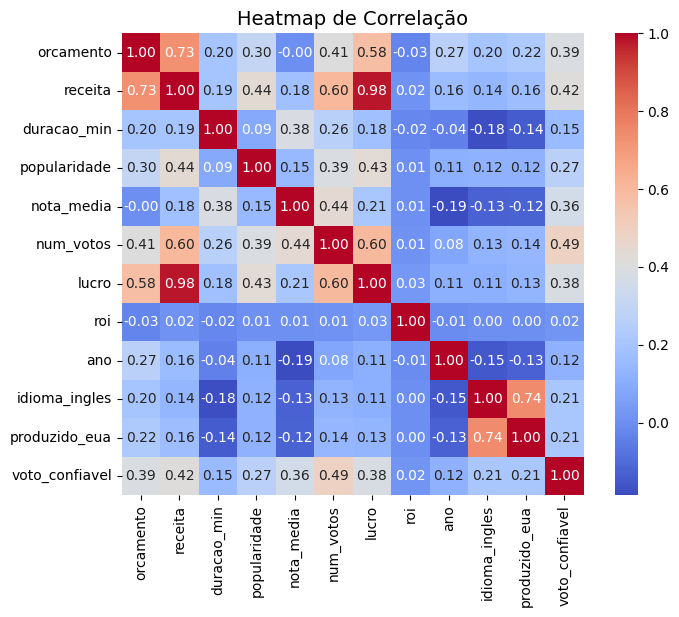

In [52]:
# Heatmap de correlação
matriz_corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)

plt.title('Heatmap de Correlação', fontsize=14)
plt.show()

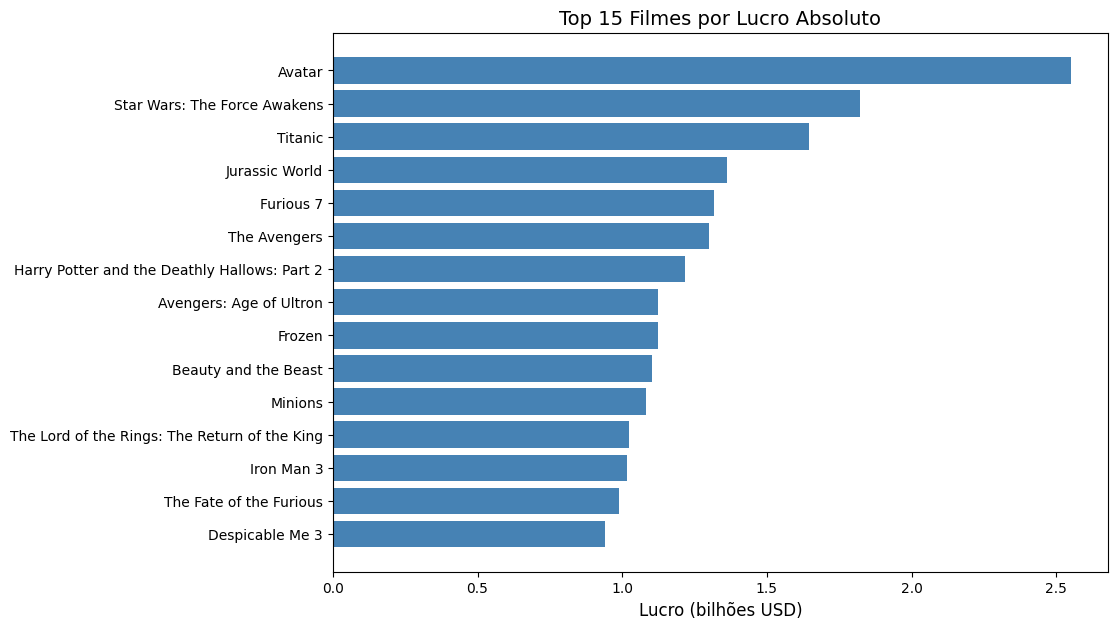

In [ ]:
# Top 15 filmes por lucro absoluto
top_lucro = df_final.nlargest(15, 'lucro')[['title', 'lucro']].sort_values('lucro')

plt.figure(figsize=(10, 7))
plt.barh(top_lucro['title'], top_lucro['lucro'] / 1e9, color='steelblue')
plt.xlabel('Lucro (bilhões USD)', fontsize=12)
plt.title('Top 15 Filmes por Lucro Absoluto', fontsize=14)
plt.show()

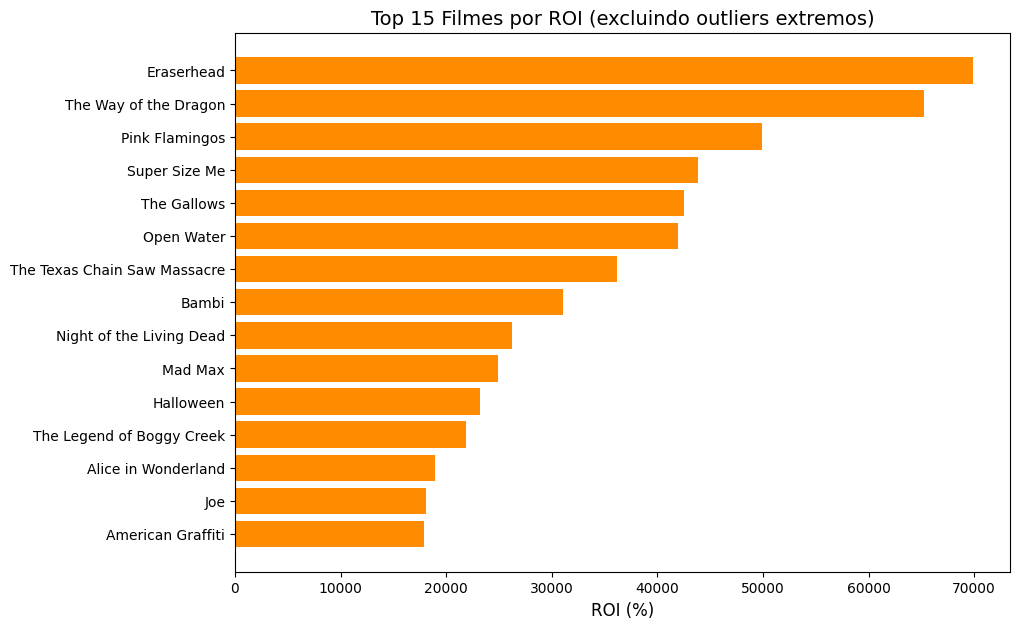

In [54]:
# Top 15 filmes por ROI
# Excluindo outliers extremos (ROI > 200.000%) para não esmagar o gráfico
# Tem dois filmes com roi maior que 200.000%
top_roi = df_final[df_final['roi'] <= 200000].nlargest(15, 'roi')[['title', 'roi']].sort_values('roi')

plt.figure(figsize=(10, 7))
plt.barh(top_roi['title'], top_roi['roi'], color='darkorange')
plt.xlabel('ROI (%)', fontsize=12)
plt.title('Top 15 Filmes por ROI (excluindo outliers extremos)', fontsize=14)
plt.show()

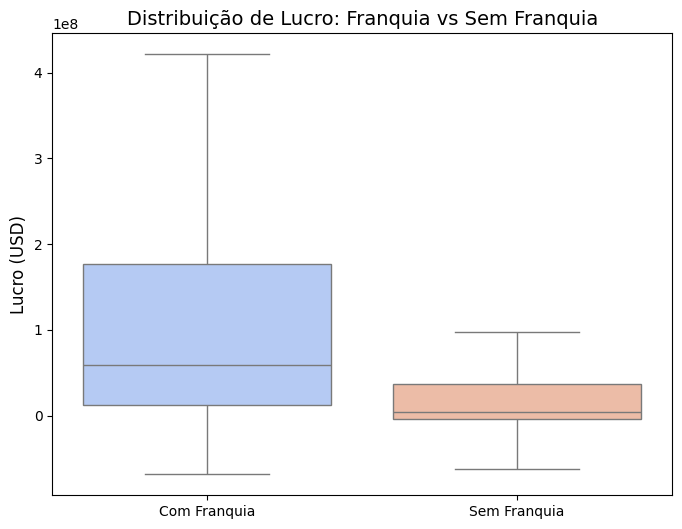

In [55]:
# Boxplot de lucro: franquia vs sem franquia
df_final['tem_franquia'] = df_final['franquia'].apply(
    lambda x: 'Com Franquia' if x != 'Sem franquia' else 'Sem Franquia'
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_final,
    x='tem_franquia',
    y='lucro',
    hue='tem_franquia',
    palette='coolwarm',
    showfliers=False
)
plt.xlabel('')
plt.ylabel('Lucro (USD)', fontsize=12)
plt.title('Distribuição de Lucro: Franquia vs Sem Franquia', fontsize=14)
plt.show()

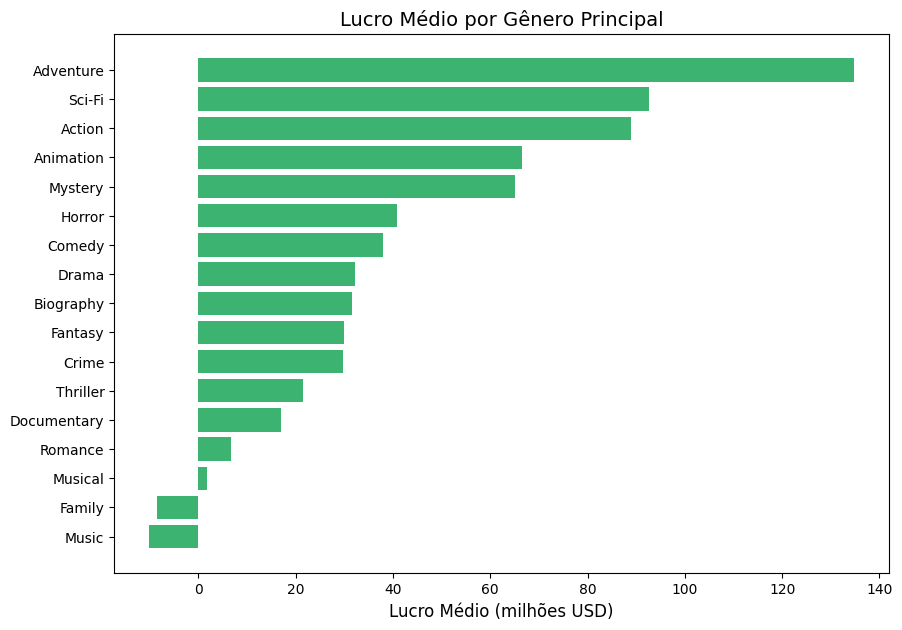

In [56]:
# Lucro médio por gênero principal
lucro_genero = (
    df_final.groupby('genero_principal')['lucro']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(lucro_genero.index, lucro_genero.values / 1e6, color='mediumseagreen')
plt.xlabel('Lucro Médio (milhões USD)', fontsize=12)
plt.title('Lucro Médio por Gênero Principal', fontsize=14)
plt.show()

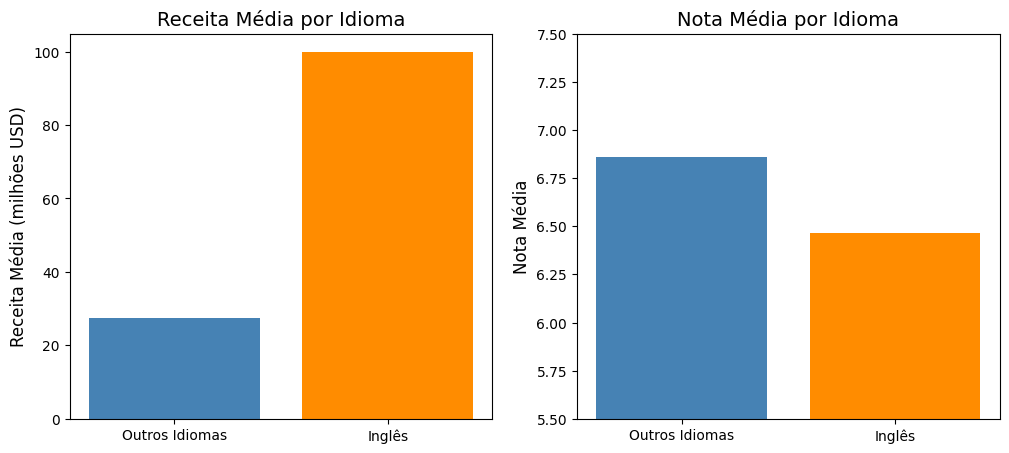

In [57]:
# Receita média e nota média por idioma (inglês vs outros)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

idioma_receita = df_final.groupby('idioma_ingles')['receita'].mean() / 1e6
idioma_nota = df_final.groupby('idioma_ingles')['nota_media'].mean()
labels = ['Outros Idiomas', 'Inglês']

axes[0].bar(labels, [idioma_receita[False], idioma_receita[True]], color=['steelblue', 'darkorange'])
axes[0].set_ylabel('Receita Média (milhões USD)', fontsize=12)
axes[0].set_title('Receita Média por Idioma', fontsize=14)

axes[1].bar(labels, [idioma_nota[False], idioma_nota[True]], color=['steelblue', 'darkorange'])
axes[1].set_ylabel('Nota Média', fontsize=12)
axes[1].set_title('Nota Média por Idioma', fontsize=14)
axes[1].set_ylim(5.5, 7.5) 

plt.show()

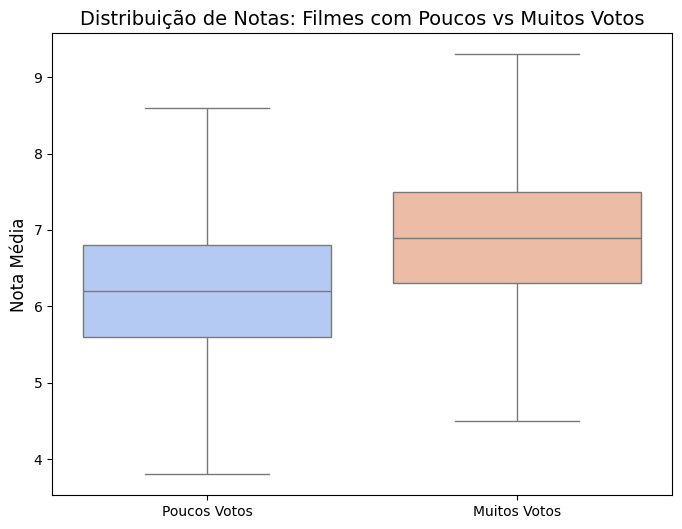

In [58]:
# Boxplot de nota_media por voto_confiavel
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_final,
    x='voto_confiavel',
    y='nota_media',
    hue='voto_confiavel',
    palette='coolwarm',
    showfliers=False
)
plt.xticks([0, 1], ['Poucos Votos', 'Muitos Votos'])
plt.xlabel('')
plt.ylabel('Nota Média', fontsize=12)
plt.title('Distribuição de Notas: Filmes com Poucos vs Muitos Votos', fontsize=14)
plt.legend().remove()
plt.show()

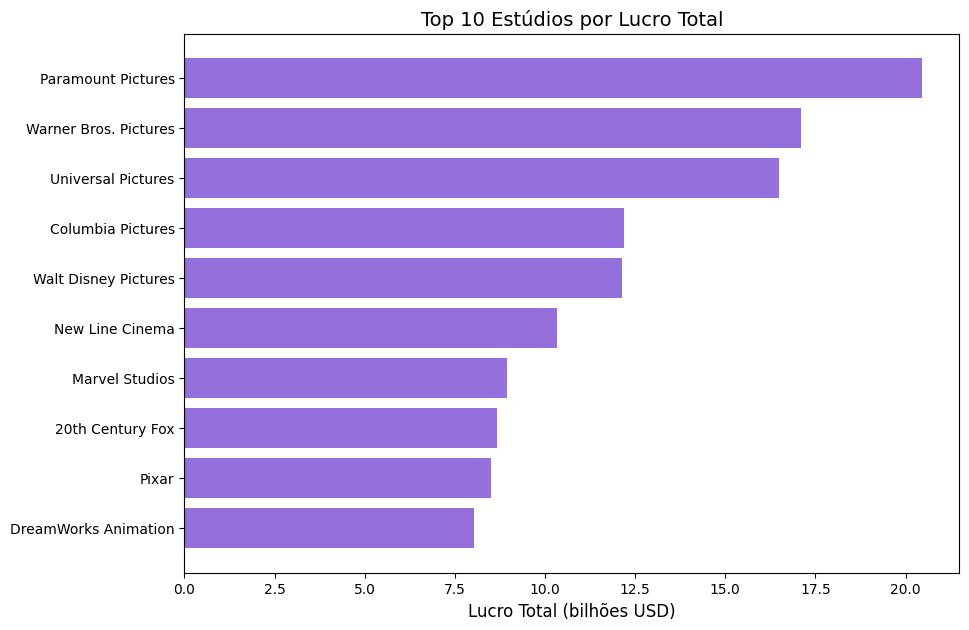

In [59]:
# Top 10 estúdios por lucro total
top_estudios = (
    df_final[df_final['estudio'] != 'Não informado']
    .groupby('estudio')['lucro']
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(top_estudios.index, top_estudios.values / 1e9, color='mediumpurple')
plt.xlabel('Lucro Total (bilhões USD)', fontsize=12)
plt.title('Top 10 Estúdios por Lucro Total', fontsize=14)
plt.show()

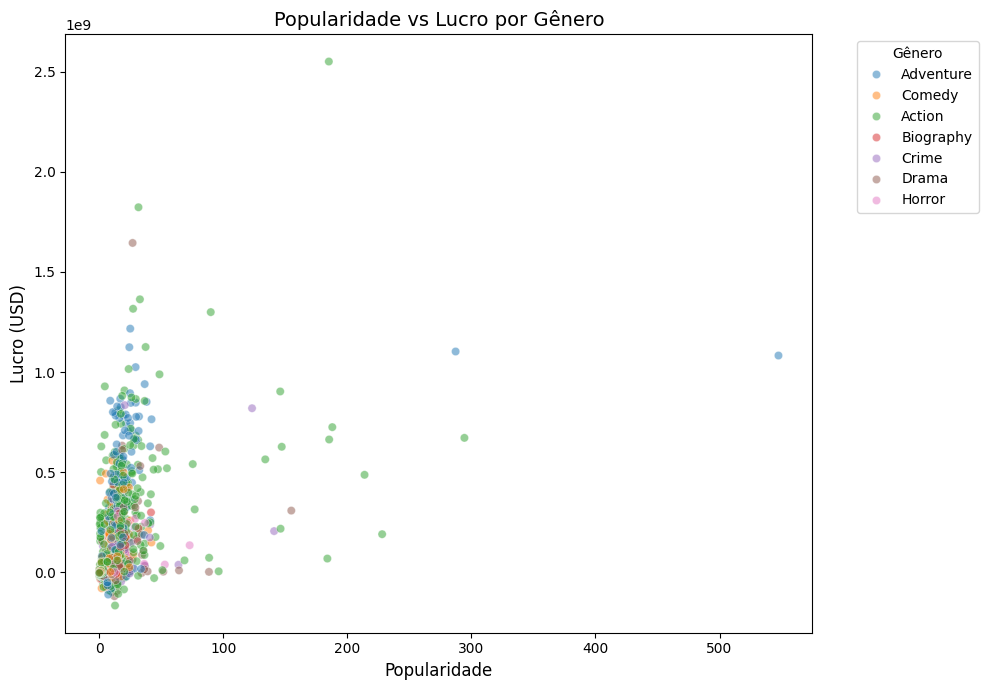

In [ ]:
# Scatter popularidade vs lucro, colorido por gênero principal
# Limitando aos gêneros com mais de 100 filmes para legenda limpa
generos_relevantes = df_final['genero_principal'].value_counts()
generos_relevantes = generos_relevantes[generos_relevantes >= 100].index
df_scatter = df_final[df_final['genero_principal'].isin(generos_relevantes)]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_scatter,
    x='popularidade',
    y='lucro',
    hue='genero_principal',
    alpha=0.5,
    palette='tab10'
)
plt.xlabel('Popularidade', fontsize=12)
plt.ylabel('Lucro (USD)', fontsize=12)
plt.title('Popularidade vs Lucro por Gênero', fontsize=14)
plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

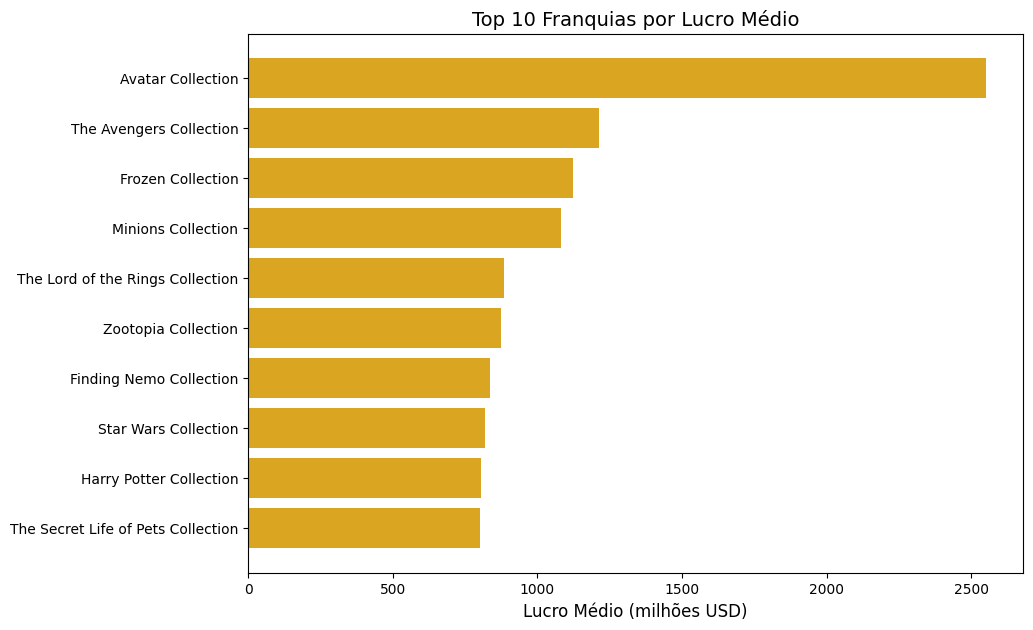

In [60]:
# Top 10 franquias por lucro médio
top_franquias = (
    df_final[df_final['franquia'] != 'Sem franquia']
    .groupby('franquia')['lucro']
    .mean()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(top_franquias.index, top_franquias.values / 1e6, color='goldenrod')
plt.xlabel('Lucro Médio (milhões USD)', fontsize=12)
plt.title('Top 10 Franquias por Lucro Médio', fontsize=14)
plt.show()

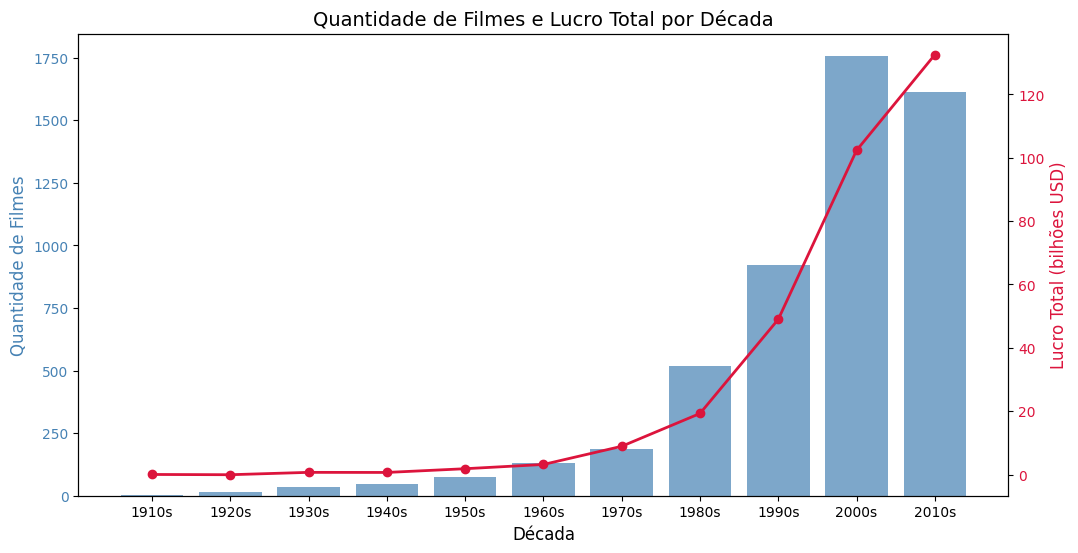

In [61]:
# Filmes por década (barras) e lucro total por década (linha)
decada_grupo = df_final.groupby('decada').agg(
    qtd_filmes=('title', 'count'),
    lucro_total=('lucro', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(decada_grupo['decada'], decada_grupo['qtd_filmes'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Década', fontsize=12)
ax1.set_ylabel('Quantidade de Filmes', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(decada_grupo['decada'], decada_grupo['lucro_total'] / 1e9, color='crimson', marker='o', linewidth=2)
ax2.set_ylabel('Lucro Total (bilhões USD)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Quantidade de Filmes e Lucro Total por Década', fontsize=14)
plt.show()

# Exportando o dataframe final

In [ ]:
# Exportando o dataframe final limpo
df_final.to_csv('df_final_limpo.csv', index=False)
df_final.shape

(5299, 23)